### MLP
- A Neural Probabilistic Language Model, Yoshua Bengio, JMLR, 2003
    - every word is embedded into a 30-dimensional space


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
words = open("names.txt",'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [5]:
chars = sorted(list(set(''.join(words))))
stoi = {s:(i+1) for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(stoi)


{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}


In [7]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words[:5]:

    print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join(itos[i] for i in context), '---->', itos[ix])
        context = context[1:] + [ix] # crop and append
    
X = torch.tensor(X)
Y = torch.tensor(Y)


emma
... ----> e
..e ----> m
.em ----> m
emm ----> a
mma ----> .
olivia
... ----> o
..o ----> l
.ol ----> i
oli ----> v
liv ----> i
ivi ----> a
via ----> .
ava
... ----> a
..a ----> v
.av ----> a
ava ----> .
isabella
... ----> i
..i ----> s
.is ----> a
isa ----> b
sab ----> e
abe ----> l
bel ----> l
ell ----> a
lla ----> .
sophia
... ----> s
..s ----> o
.so ----> p
sop ----> h
oph ----> i
phi ----> a
hia ----> .


In [8]:
C = torch.randn((27,2))

emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [10]:
W1 = torch.randn((6,100))
b1 = torch.randn(100)

In [12]:
emb @ W1 + b1

RuntimeError: mat1 and mat2 shapes cannot be multiplied (96x2 and 6x100)

In [15]:
torch.cat((emb[:,0,:], emb[:,1,:], emb[:,2,:]), dim=1).shape

torch.Size([32, 6])

In [16]:
torch.cat(torch.unbind(emb,dim=1),dim=1).shape

torch.Size([32, 6])

In [20]:
# in each tensor, there is something called the underlying storage
a = torch.arange(18)
a.storage()

# storage is always as a one-dimension vector, when we call .view(), we are manipulating some of the attributes of that tensor that dictate how this sequence is interpreted to be a n-dimensional tensor
a.view(3,3,2)

emb.view(32,6).shape

torch.Size([32, 6])

In [ ]:
h = torch.tanh(emb.view(emb.shape[0], 6) @ W1 + b1)

torch.Size([32, 100])

In [25]:
W2 = torch.randn((100,27))
b2 = torch.randn(27)


In [26]:
logits = h @ W2 + b2
logits.shape

torch.Size([32, 27])

In [37]:
counts = logits.exp()
probs = counts / counts.sum(dim=1, keepdim=True)
probs.shape

torch.Size([32, 27])

In [38]:
loss = -probs[torch.arange(32),Y].log().mean()
loss

tensor(inf)

In [31]:
# now made respectable

In [32]:
X.shape, Y.shape

(torch.Size([32, 3]), torch.Size([32]))

In [34]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2), generator=g)
W1 = torch.randn((6,100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100,27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C,W1,b1,W2,b2]


In [35]:
sum(p.numel() for p in parameters)

3481

In [40]:
emb = C[X]
h = torch.tanh(emb.view(-1,6) @ W1 + b1)
logits = h @ W2 + b2
counts = logits.exp()
probs = counts / counts.sum(dim=1, keepdim=True)
loss = -probs[torch.arange(32),Y].log().mean()
loss

tensor(17.7697)

In [ ]:
F.cross_entropy(logits, Y) # parameter is logits

# more efficient
# much more numerically well-behaved

tensor(17.7697)

In [45]:
# true training 

# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words:
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix] # crop and append
    
X = torch.tensor(X)
Y = torch.tensor(Y)
num = X.numel()

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2), generator=g)
W1 = torch.randn((6,100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100,27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C,W1,b1,W2,b2]

for p in parameters:
    p.requires_grad = True

for _ in range(100):

    # forward pass
    emb = C[X]
    h = torch.tanh(emb.view(-1,6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y)

    for p in parameters:
        p.grad = None

    # backward pass
    loss.backward()

    # update
    for p in parameters:
        p.data -= 0.1 * p.grad

print(loss.item())
    

    

3.5892510414123535


In [47]:
# use batch

# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words:
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix] # crop and append
    
X = torch.tensor(X)
Y = torch.tensor(Y)
num = X.numel()

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2), generator=g)
W1 = torch.randn((6,100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100,27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C,W1,b1,W2,b2]

for p in parameters:
    p.requires_grad = True

for _ in range(100):

    ix = torch.randint(0,X.shape[0], (32,))

    # forward pass
    emb = C[X[ix]] # (32,3,2)
    h = torch.tanh(emb.view(-1,6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])

    for p in parameters:
        p.grad = None

    # backward pass
    loss.backward()

    # update
    for p in parameters:
        p.data -= 0.1 * p.grad

print(loss.item())
    

    

3.698078155517578


In [48]:
emb = C[X]
h = torch.tanh(emb.view(-1,6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y)
loss.item()

3.7286667823791504

In [53]:
# add adjust learning rate
lre = torch.linspace(-3,0,1000)
lrs = 10**lre

lri = []
lossi = []

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words:
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix] # crop and append
    
X = torch.tensor(X)
Y = torch.tensor(Y)
num = X.numel()

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2), generator=g)
W1 = torch.randn((6,100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100,27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C,W1,b1,W2,b2]

for p in parameters:
    p.requires_grad = True

for i in range(1000):

    ix = torch.randint(0,X.shape[0], (32,))

    # forward pass
    emb = C[X[ix]] # (32,3,2)
    h = torch.tanh(emb.view(-1,6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])

    for p in parameters:
        p.grad = None

    # backward pass
    loss.backward()

    # update
    for p in parameters:
        p.data -= lrs[i] * p.grad
    
    # track stats 
    lri.append(lre[i].item())
    lossi.append(loss.item())

print(loss.item())

6.3869547843933105


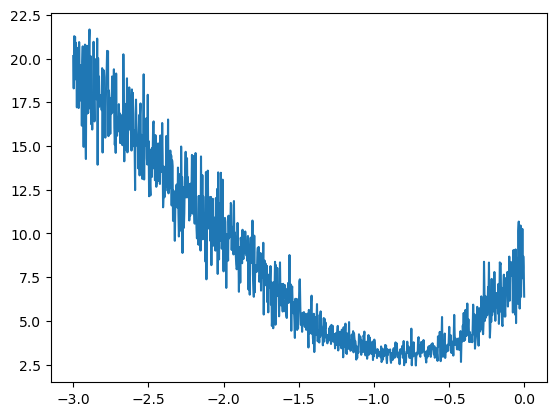

In [54]:
plt.plot(lri, lossi)

In [62]:
# training split, dev/validation split, test split
# 80%, 10%, 10%
# training the parameters, train the hyperparameters, evaluate the performance of the model

def build_dataset(words):
    block_size = 3 # context length: how many characters do we take to predict the next one?
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append
        
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X,Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])


In [63]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2), generator=g)
W1 = torch.randn((6,100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100,27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C,W1,b1,W2,b2]

for p in parameters:
    p.requires_grad = True

for i in range(10000):

    ix = torch.randint(0,Xtr.shape[0], (32,))

    # forward pass
    emb = C[Xtr[ix]] # (32,3,2)
    h = torch.tanh(emb.view(-1,6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])

    for p in parameters:
        p.grad = None

    # backward pass
    loss.backward()

    # update
    for p in parameters:
        p.data -= 0.1 * p.grad

print(loss.item())

2.7763290405273438


In [64]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1,6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss.item()

2.525738477706909

In [66]:
# scaling up the size
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2), generator=g)
W1 = torch.randn((6,300), generator=g)
b1 = torch.randn(300, generator=g)
W2 = torch.randn((300,27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C,W1,b1,W2,b2]
print(sum(p.numel() for p in parameters))

lossi = []
stepi = []


for p in parameters:
    p.requires_grad = True

for i in range(10000):

    ix = torch.randint(0,Xtr.shape[0], (32,))

    # forward pass
    emb = C[Xtr[ix]] # (32,3,2)
    h = torch.tanh(emb.view(-1,6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])

    for p in parameters:
        p.grad = None

    # backward pass
    loss.backward()

    # update
    lr = 0.1
    for p in parameters:
        p.data -= lr * p.grad

    # track stats
    stepi.append(i)
    lossi.append(loss.item())

# print(loss.item())

10281


2.6756808757781982

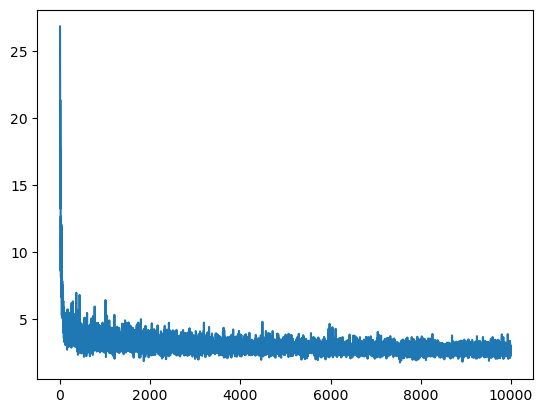

In [68]:
plt.plot(stepi, lossi)
lossi[-1]